# Household Behavior over the Life Cycle Exam 2026

## Setup

In [23]:
%load_ext autoreload
%autoreload 2

import numpy as np
from scipy.optimize import minimize, minimize_scalar, root_scalar
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Labor model initialization

In [24]:
# load local model file and initialize model class
from LaborCohortModel import LaborCohortModelClass
model = LaborCohortModelClass()

In [25]:
%time model.solve()
%time model.simulate()

CPU times: user 15.1 s, sys: 913 ms, total: 16 s
Wall time: 5.53 s
CPU times: user 14.3 s, sys: 147 ms, total: 14.4 s
Wall time: 14.9 s


### Q2: Simulate two versions of the model as $\tau=0$ and $\tau=0.3$. 

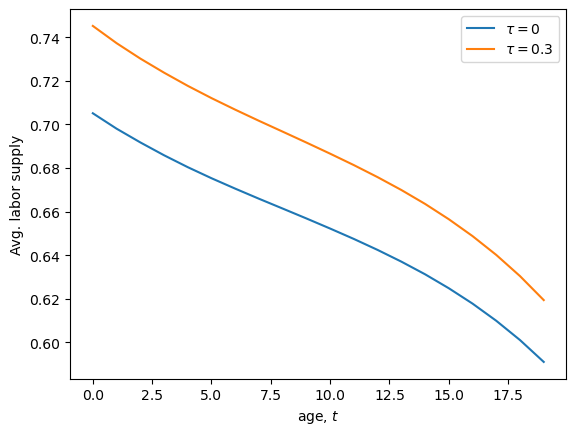

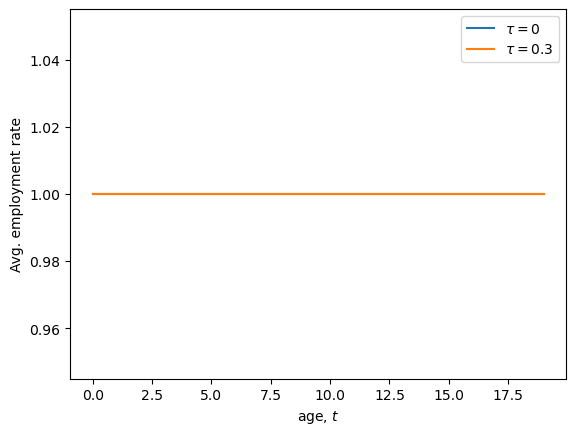

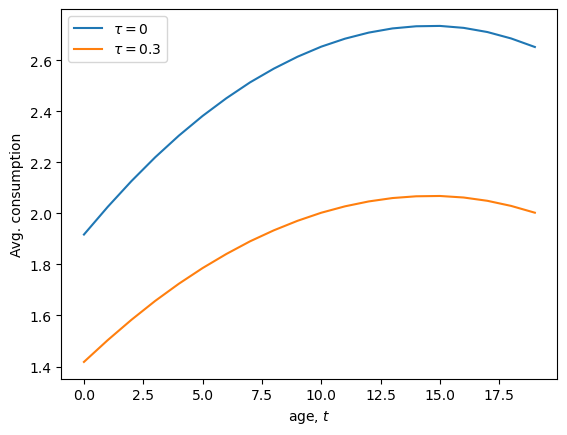

In [26]:
# build the two versions (tax is already a parameter)
model_notax = LaborCohortModelClass(par={'tau':0.0})
model_tax   = LaborCohortModelClass(par={'tau':0.3})
for m in (model_notax, model_tax):
    m.solve()
    m.simulate()

reduce = {'h':   lambda sim: np.nanmean(sim.h, axis=0),
          'emp': lambda sim: np.mean(sim.h > 1e-6, axis=0),
          'c':   lambda sim: np.nanmean(sim.c, axis=0)}
labels = {'h':'labor supply', 'emp':'employment rate', 'c':'consumption'}

for val in ('h','emp','c'):
    var1 = reduce[val](model_notax.sim)
    var2 = reduce[val](model_tax.sim)
    fig, ax = plt.subplots()
    ax.plot(var1, label=r'$\tau=0$')
    ax.plot(var2, label=r'$\tau=0.3$')
    ax.set(ylabel=f'Avg. {labels[val]}', xlabel='age, $t$')
    ax.legend()

### Q3: Government


In [27]:
model = LaborCohortModelClass()
model.solve()
model.simulate()

# Summing over all periods and individuals
G3 = model.sim.G.sum()
print(f'G3 = {G3:.3f}')

G3 = 808284.826


[Text(0.5, 0, 'tax rate, $\\tau$'),
 Text(0, 0.5, 'government budget, $G(\\theta)$')]

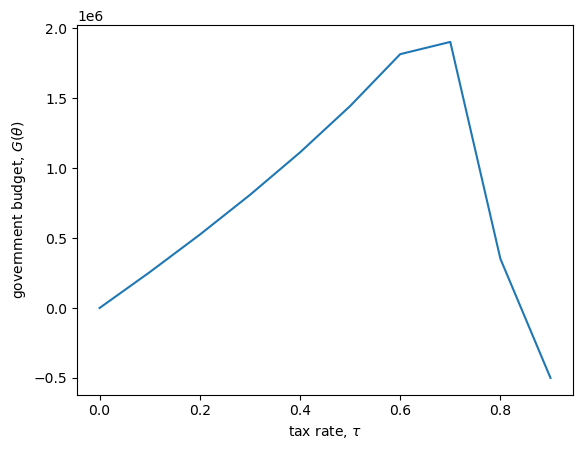

In [28]:
taus = np.arange(0.0,1.0,0.1)   
G_tau = np.zeros(taus.size)

for j,tau in enumerate(taus):
    m = LaborCohortModelClass(par={'tau':tau})
    m.solve()
    m.simulate()
    G_tau[j] = m.sim.G.sum()        

fig,ax = plt.subplots()
ax.plot(taus,G_tau)
ax.set(xlabel=r'tax rate, $\tau$', ylabel=r'government budget, $G(\theta)$')

### Q4:New unemployment benefit


In [29]:
# baseline = Q3 model: pi_1 = 0 collapses eq (7) back to pi_t = pi_0, tau = 0.3 by default
model_base = LaborCohortModelClass(name='base')
model_base.solve()
model_base.simulate()

# reform = old-age subsidy: pi_1 = 0.6
model_reform = LaborCohortModelClass(name='reform', par={'pi_1':0.6})
model_reform.solve()
model_reform.simulate()

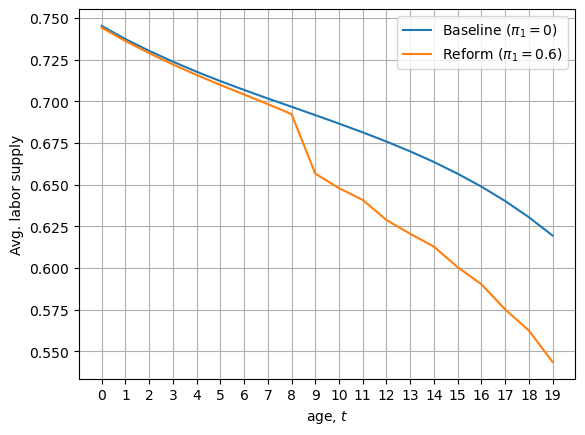

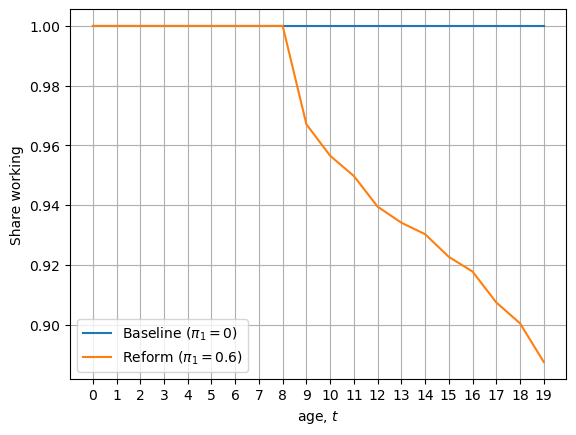

In [30]:
age = np.arange(model_base.par.simT)

# average labor supply over age
fig,ax = plt.subplots()
ax.plot(age, np.nanmean(model_base.sim.h,   axis=0), label='Baseline ($\\pi_1=0$)')
ax.plot(age, np.nanmean(model_reform.sim.h, axis=0), label='Reform ($\\pi_1=0.6$)')
ax.set_xlabel('age, $t$'); ax.set_ylabel('Avg. labor supply'); ax.legend()
ax.xaxis.set_major_locator(plt.MultipleLocator(1))   # ticks/gridlines hver 1
ax.grid(True)

# share working over age
fig,ax = plt.subplots()
ax.plot(age, np.nanmean(model_base.sim.h   > 1e-6, axis=0), label='Baseline ($\\pi_1=0$)')
ax.plot(age, np.nanmean(model_reform.sim.h > 1e-6, axis=0), label='Reform ($\\pi_1=0.6$)')
ax.set_xlabel('age, $t$'); ax.set_ylabel('Share working'); ax.legend()
ax.xaxis.set_major_locator(plt.MultipleLocator(1))   # ticks/gridlines hver 1
ax.grid(True)

### 4.c average government budget balance across years

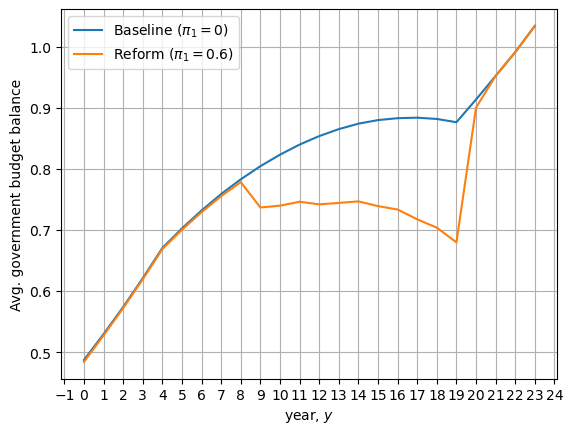

In [31]:
# average budget balance per person, in each calendar year y = t + b
def budget_by_year(model):
    sim = model.sim
    years = np.arange(model.par.num_years)            # code years 0..23
    return years, np.array([np.nanmean(sim.G[sim.y==y]) for y in years])

years, G_base   = budget_by_year(model_base)
_,     G_reform = budget_by_year(model_reform)

fig,ax = plt.subplots()
ax.plot(years, G_base,   label='Baseline ($\\pi_1=0$)')
ax.plot(years, G_reform, label='Reform ($\\pi_1=0.6$)')
ax.set_xlabel('year, $y$'); ax.set_ylabel('Avg. government budget balance'); ax.legend()
ax.xaxis.set_major_locator(plt.MultipleLocator(1))   
ax.grid(True)

### 5.b

In [ ]:
from scipy.optimize import minimize_scalar

# baseline total budget G3 
model_base = LaborCohortModelClass(name='base')          # pi_1=0, tau_1=0
model_base.solve(); model_base.simulate()
G3 = np.nansum(model_base.sim.G)

# total budget of the financed reform as a function of the surtax
def G_reform(tau_1):
    m = LaborCohortModelClass(par={'pi_1':0.6, 'tau_1':tau_1})
    m.solve(); m.simulate()
    return np.nansum(m.sim.G)

# surtax that brings the reform's budget back to baseline
obj = lambda tau_1: (G3 - G_reform(tau_1))**2
res = minimize_scalar(obj, bounds=(0.015, 0.025), method='bounded')
tau_1_star = res.x
print(f'tau_1* = {tau_1_star:.4f}')

tau_1* = 0.0236


### 5.c+d

In [33]:
from consav.linear_interp import interp_1d   # same interpolator the model uses

def welfare(model):
    par, sol, sim = model.par, model.sol, model.sim
    W = np.zeros(par.simN)
    for i in range(par.simN):
        b = sim.b_init[i]                              # birth cohort
        W[i] = interp_1d(par.k_grid, sol.V[0,b,:,0], sim.k_init[i])   # value at birth, at initial k
    return W

In [ ]:
model_base  = LaborCohortModelClass(par={'tau':0.3, 'pi_1':0.0, 'tau_1':0.0})
model_base.solve()

model_5star = LaborCohortModelClass(par={'tau':0.3, 'pi_1':0.6, 'tau_1':tau_1_star})
model_5star.solve()

# welfare per person under each policy (same birth states by construction) 
W_base  = welfare(model_base)
W_5star = welfare(model_5star)

# per cohort: avg welfare under reform, change vs baseline, share better off 
b_init = model_base.sim.b_init
for b in model_base.par.b_grid:
    mask          = (b_init == b)
    avg_reform    = W_5star[mask].mean()
    avg_baseline  = W_base[mask].mean()
    avg_change    = (W_5star[mask] - W_base[mask]).mean()
    share_better  = (W_5star[mask] > W_base[mask]).mean()   
    print(f'cohort {b}: avg W (base) = {avg_baseline:7.3f} | avg W (reform) = {avg_reform:7.3f} '
          f'| change = {avg_change:+.5f} | share better off = {share_better:5.1%}')

cohort 0: avg W (base) = -30.656 | avg W (reform) = -30.718 | change = -0.06236 | share better off =  0.0%
cohort 1: avg W (base) = -29.142 | avg W (reform) = -29.387 | change = -0.24535 | share better off =  0.0%
cohort 2: avg W (base) = -27.702 | avg W (reform) = -27.961 | change = -0.25931 | share better off =  0.0%
cohort 3: avg W (base) = -26.338 | avg W (reform) = -26.607 | change = -0.26918 | share better off =  0.0%
cohort 4: avg W (base) = -25.034 | avg W (reform) = -25.313 | change = -0.27846 | share better off =  0.0%


### 6.b

In [ ]:
# reference models, tau_1 = 0 in all
model_base   = LaborCohortModelClass(par={'pi_1':0.0})   # Q3 baseline
model_reform = LaborCohortModelClass(par={'pi_1':0.6})   # Q4 anticipated reform
for m in (model_base, model_reform):
    m.solve(); m.simulate()

# unanticipated reform: split decision rules by year
model_unant = LaborCohortModelClass(par={'pi_1':0.6})
for t in range(model_unant.par.T):
    for b in range(model_unant.par.Nb):
        year = t + b
        model_unant.sol.h[t,b] = (model_base.sol.h[t,b] if year < model_unant.par.retire_year
                                  else model_reform.sol.h[t,b])
model_unant.simulate()

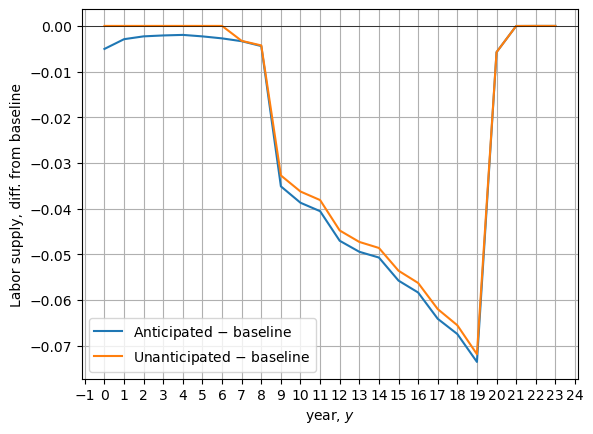

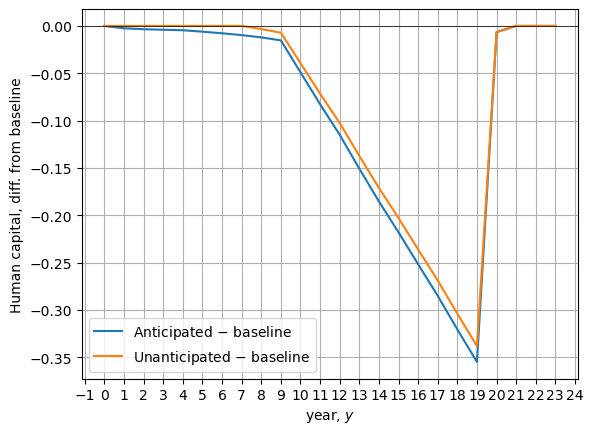

In [36]:
# aggregate by year and plot differences from baseline
years = np.arange(model_base.par.num_years)
mean_by_year = lambda vals, yr: np.array([np.nanmean(vals[yr==y]) for y in years])

# labor supply, by year
h_base = mean_by_year(model_base.sim.h,   model_base.sim.y)
h_ant  = mean_by_year(model_reform.sim.h, model_reform.sim.y)
h_un   = mean_by_year(model_unant.sim.h,  model_unant.sim.y)

# human capital, by year
k_base = mean_by_year(model_base.sim.k,   model_base.sim.y)
k_ant  = mean_by_year(model_reform.sim.k, model_reform.sim.y)
k_un   = mean_by_year(model_unant.sim.k,  model_unant.sim.y)

# labor supply: difference from baseline
fig,ax = plt.subplots()
ax.plot(years, h_ant - h_base, label='Anticipated $-$ baseline')
ax.plot(years, h_un  - h_base, label='Unanticipated $-$ baseline')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('year, $y$'); ax.set_ylabel('Labor supply, diff. from baseline'); ax.legend()
ax.xaxis.set_major_locator(plt.MultipleLocator(1))   # tick/gridline every year
ax.grid(True)

# human capital: difference from baseline
fig,ax = plt.subplots()
ax.plot(years, k_ant - k_base, label='Anticipated $-$ baseline')
ax.plot(years, k_un  - k_base, label='Unanticipated $-$ baseline')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('year, $y$'); ax.set_ylabel('Human capital, diff. from baseline'); ax.legend()
ax.xaxis.set_major_locator(plt.MultipleLocator(1))   # tick/gridline every year
ax.grid(True)

### 7.b

In [37]:
r_path = np.array([0,0,0,1,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,1])
model_rec = LaborCohortModelClass(par={'lambda_1':-0.5})
model_rec.par.r_sim = r_path
model_rec.solve(); model_rec.simulate()

model_rec.simulate()   # simulate along the realized path r_path

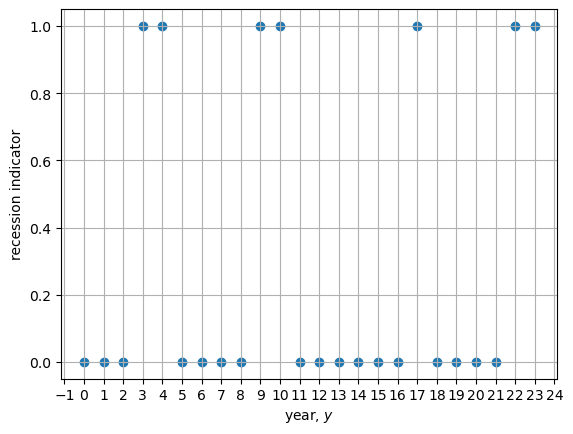

In [38]:
fig,ax = plt.subplots()
ax.scatter(np.arange(r_path.size), r_path)
ax.set_xlabel('year, $y$'); ax.set_ylabel('recession indicator')
ax.xaxis.set_major_locator(plt.MultipleLocator(1)); ax.grid(True)

### 7.c

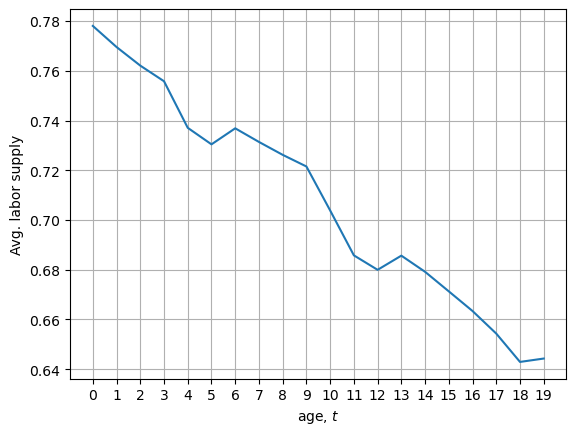

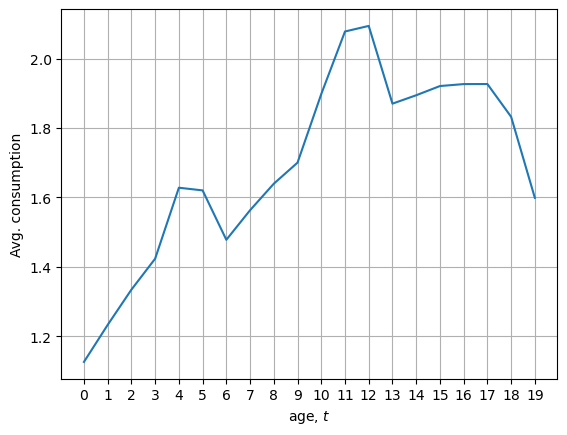

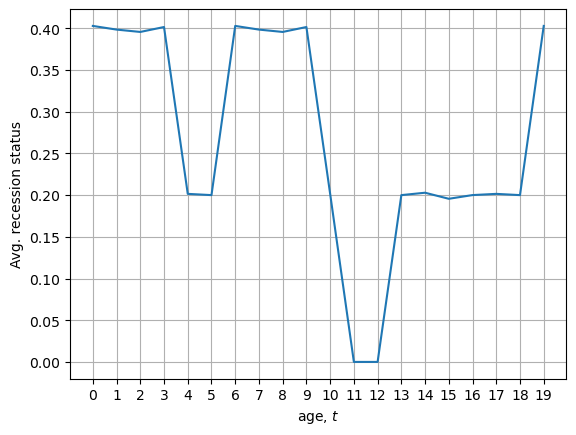

In [39]:
age = np.arange(model_rec.par.T)   # 0..19
profiles_age = {
    'labor supply':     np.nanmean(model_rec.sim.h, axis=0),
    'consumption':      np.nanmean(model_rec.sim.c, axis=0),
    'recession status': np.nanmean(model_rec.sim.r, axis=0),
}
for name, prof in profiles_age.items():
    fig,ax = plt.subplots()
    ax.plot(age, prof)
    ax.set_xlabel('age, $t$'); ax.set_ylabel(f'Avg. {name}')
    ax.xaxis.set_major_locator(plt.MultipleLocator(1)); ax.grid(True)

### 7.d

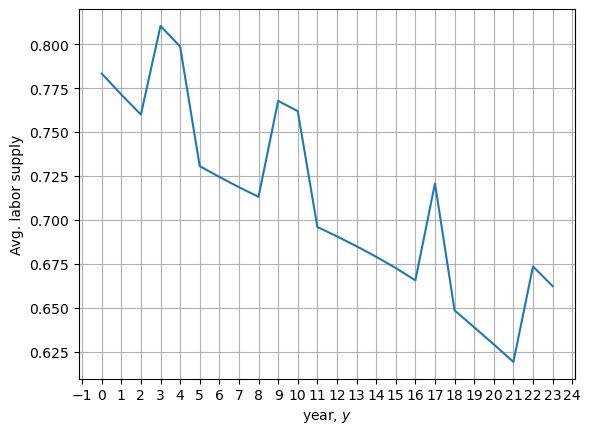

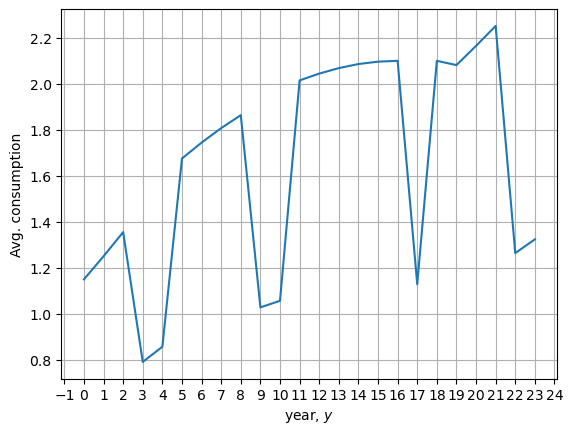

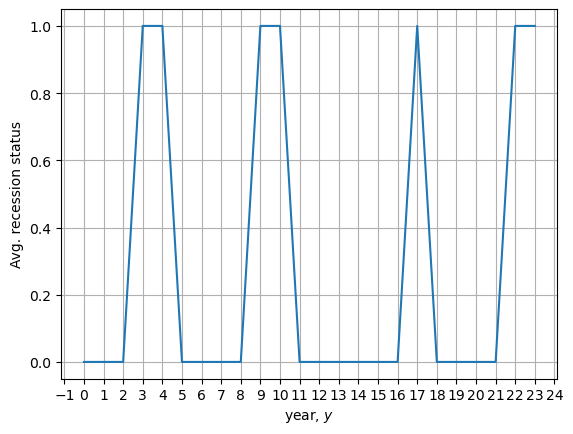

In [40]:
years = np.arange(model_rec.par.num_years)   # 0..23
yy = model_rec.sim.y
profiles_year = {
    'labor supply':     np.array([model_rec.sim.h[yy==y].mean() for y in years]),
    'consumption':      np.array([model_rec.sim.c[yy==y].mean() for y in years]),
    'recession status': np.array([model_rec.sim.r[yy==y].mean() for y in years]),
}
for name, prof in profiles_year.items():
    fig,ax = plt.subplots()
    ax.plot(years, prof)
    ax.set_xlabel('year, $y$'); ax.set_ylabel(f'Avg. {name}')
    ax.xaxis.set_major_locator(plt.MultipleLocator(1)); ax.grid(True)